# 02 — Clustering & Information Gain

**input:** `data/movies.pkl` and `data/embeddings.npy` (from notebook 01)

**Does one thing:**
1. K-Means on embeddings
2. Computes Entropy and Information Gain
3. Silhouette score for cluster quality
4. A simple visualization

**output:** `data/cluster_results.pkl`

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

DATA_DIR = Path('../data')

# load outputs from notebook 01
movies     = pd.read_pickle(DATA_DIR / 'movies.pkl')
embeddings = np.load(DATA_DIR / 'embeddings.npy')

print(f'Movies: {len(movies)}')
print(f'Embeddings: {embeddings.shape}')

Movies: 3883
Embeddings: (3883, 384)


### Part 1 — Entropy & Information Gain

In [2]:
Movies: 3883
Embeddings: (3883, 384)
def entropy(candidate_indices: list) -> float:
    """
    H(C) = log2(|C|) under uniform distribution.
    If only 1 item remains, uncertainty is zero.
    """
    n = len(candidate_indices)
    if n <= 1:
        return 0.0
    return np.log2(n)


def expected_entropy(partition: list[list]) -> float:
    """
    E[H] = sum_k  P(G_k) * H(G_k)
    P(G_k) = |G_k| / |C|   (uniform assumption)
    """
    total = sum(len(g) for g in partition)
    if total == 0:
        return 0.0
    return sum((len(g) / total) * entropy(g) for g in partition)


def information_gain(candidate_indices: list, partition: list[list]) -> float:
    """
    IG = H(C) - E[H(partition)]
    Higher value = better partition
    """
    return entropy(candidate_indices) - expected_entropy(partition)


# ── sanity check ─────────────────────────────────────────
C = list(range(100))

balanced   = [list(range(0,25)), list(range(25,50)),
              list(range(50,75)), list(range(75,100))]
unbalanced = [list(range(0,90)), list(range(90,100))]

print(f'H(C=100)            = {entropy(C):.3f} bits')
print(f'IG balanced   (25x4)= {information_gain(C, balanced):.3f}   ← should be higher')
print(f'IG unbalanced (90/10)= {information_gain(C, unbalanced):.3f}  ← should be lower')

H(C=100)            = 6.644 bits
IG balanced   (25x4)= 2.000   ← should be higher
IG unbalanced (90/10)= 0.469  ← should be lower


### Part 2 — K-Means Clustering

In [3]:
def cluster_candidates(
    candidate_indices: list[int],
    all_embeddings: np.ndarray,
    k: int
) -> tuple[list[list[int]], np.ndarray]:
    """
    K-Means on embeddings of candidate set items.

    Returns:
        partition : list of k lists, each containing item indices
        labels    : cluster label for each candidate
    """
    k = min(k, len(candidate_indices))  # K cannot exceed the number of items
    if k == 1:
        return [candidate_indices], np.zeros(len(candidate_indices), dtype=int)

    embs   = all_embeddings[candidate_indices]
    km     = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(embs)

    partition = [[] for _ in range(k)]
    for idx, lbl in zip(candidate_indices, labels):
        partition[lbl].append(idx)

    partition = [p for p in partition if p]  # remove empty clusters
    return partition, labels


# ── test on the first 500 movies ───────────────────────────────
test_indices = list(range(500))
partition, labels = cluster_candidates(test_indices, embeddings, k=5)

print('Cluster sizes:')
for i, g in enumerate(partition):
    # how many dominant genres?
    top_genres = movies.iloc[g]['genres_clean'].str.split().explode().value_counts().head(3).index.tolist()
    print(f'  Cluster {i}: {len(g)} items  |  top genres: {top_genres}')

Cluster sizes:
  Cluster 0: 129 items  |  top genres: ['Comedy', 'Drama', 'Action']
  Cluster 1: 97 items  |  top genres: ['Thriller', 'Drama', 'Action']
  Cluster 2: 76 items  |  top genres: ['Adventure', 'Action', "Children's"]
  Cluster 3: 71 items  |  top genres: ['Romance', 'Drama', 'Comedy']
  Cluster 4: 127 items  |  top genres: ['Drama', 'War', 'Action']


### Part 3 — Silhouette Score (cluster quality)

In [4]:
# silhouette: between -1 and 1, closer to 1 = better clustering
embs_test = embeddings[test_indices]
sil = silhouette_score(embs_test, labels)
ig  = information_gain(test_indices, partition)

print(f'Silhouette Score : {sil:.4f}   (range: -1 to 1, higher = better)')
print(f'Information Gain : {ig:.4f} bits')

Silhouette Score : 0.0545   (range: -1 to 1, higher = better)
Information Gain : 2.2784 bits


### Part 4 — IG vs K (how many clusters is best?)

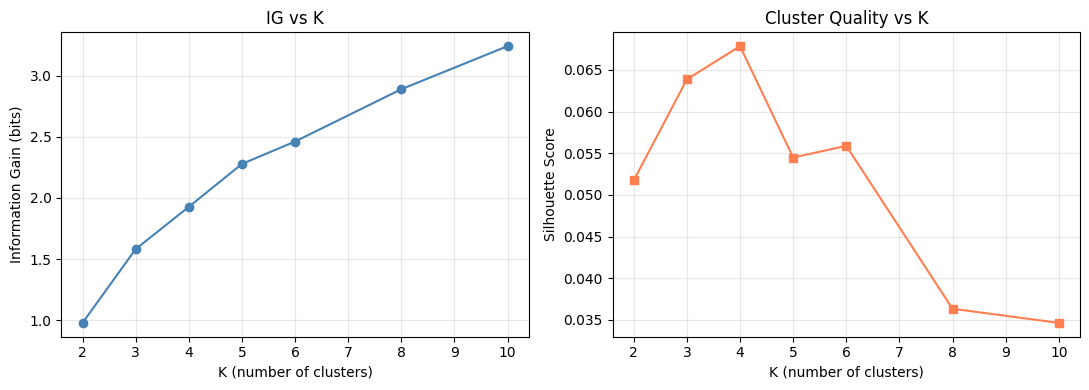

Best K by silhouette: 4


In [5]:
# examine how IG and silhouette vary across different K values
k_values = [2, 3, 4, 5, 6, 8, 10]
ig_scores  = []
sil_scores = []

for k in k_values:
    part, lbls = cluster_candidates(test_indices, embeddings, k=k)
    ig_scores.append(information_gain(test_indices, part))
    sil_scores.append(silhouette_score(embs_test, lbls))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(k_values, ig_scores, marker='o', color='steelblue')
ax1.set_xlabel('K (number of clusters)')
ax1.set_ylabel('Information Gain (bits)')
ax1.set_title('IG vs K')
ax1.grid(alpha=0.3)

ax2.plot(k_values, sil_scores, marker='s', color='coral')
ax2.set_xlabel('K (number of clusters)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Cluster Quality vs K')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path('../results') / 'ig_vs_k.png', dpi=130)
plt.show()

# best K by silhouette score
best_k = k_values[np.argmax(sil_scores)]
print(f'Best K by silhouette: {best_k}')

### Part 5 — Save

In [6]:
import pickle

cluster_results = {
    'k_values':   k_values,
    'ig_scores':  ig_scores,
    'sil_scores': sil_scores,
    'best_k':     best_k,
}

with open(DATA_DIR / 'cluster_results.pkl', 'wb') as f:
    pickle.dump(cluster_results, f)

print('Saved: data/cluster_results.pkl')
print()
print('Done.')



Saved: data/cluster_results.pkl

Done.
